In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart_disease_uci.csv')
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [3]:
## 1. Informasi Dasar Dataset

In [4]:
# Dimensi dataset
print("="*60)
print("DIMENSI DATASET")
print("="*60)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nNama kolom:\n{df.columns.tolist()}")

DIMENSI DATASET
Jumlah baris: 920
Jumlah kolom: 16

Nama kolom:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [5]:
# Tipe data setiap kolom
print("="*60)
print("TIPE DATA SETIAP KOLOM")
print("="*60)
print(df.dtypes)

TIPE DATA SETIAP KOLOM
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


In [6]:
# Info lengkap dataset
print("="*60)
print("INFO DATASET")
print("="*60)
df.info()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## 2. Statistik Deskriptif

In [7]:
# Statistik deskriptif untuk kolom numerik
print("="*60)
print("STATISTIK DESKRIPTIF - KOLOM NUMERIK")
print("="*60)
df.describe().T

STATISTIK DESKRIPTIF - KOLOM NUMERIK


,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [8]:
# Statistik deskriptif untuk kolom kategorikal
print("="*60)
print("STATISTIK DESKRIPTIF - KOLOM KATEGORIKAL")
print("="*60)
df.describe(include='object').T

STATISTIK DESKRIPTIF - KOLOM KATEGORIKAL


,count,unique,top,freq
sex,920,2,Male,726
dataset,920,4,Cleveland,304
cp,920,4,asymptomatic,496
fbs,830,2,False,692
restecg,918,3,normal,551
exang,865,2,False,528
slope,611,3,flat,345
thal,434,3,normal,196


## 3. Analisis Missing Values

In [9]:
# Cek missing values
print("="*60)
print("MISSING VALUES")
print("="*60)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False))
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

MISSING VALUES
          Missing Values  Percentage (%)
ca                   611       66.413043
thal                 486       52.826087
slope                309       33.586957
fbs                   90        9.782609
oldpeak               62        6.739130
trestbps              59        6.413043
exang                 55        5.978261
thalch                55        5.978261
chol                  30        3.260870
restecg                2        0.217391

Total Missing Values: 1759


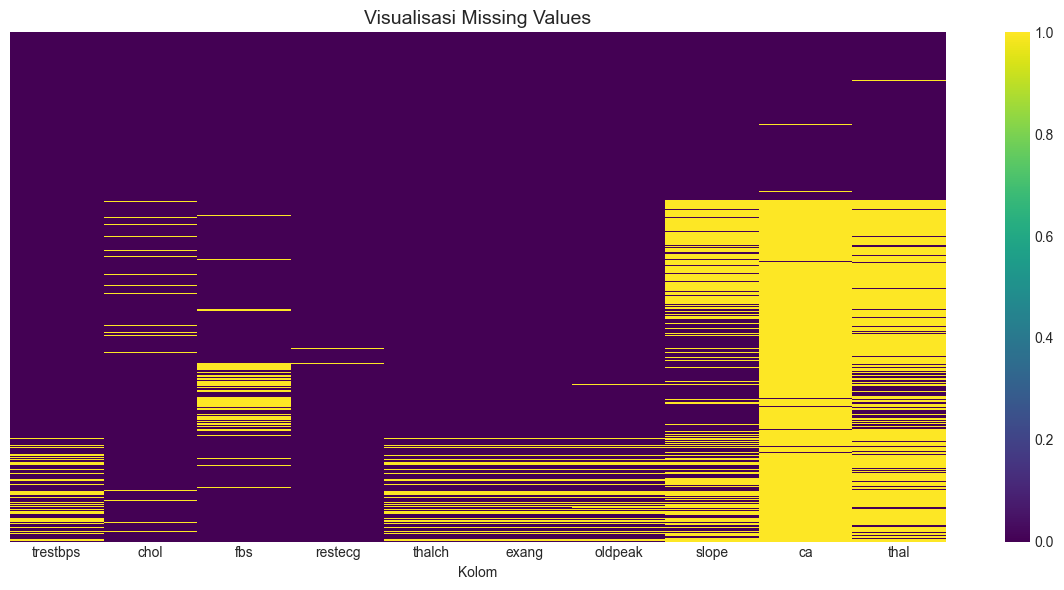

In [10]:
# Visualisasi missing values
plt.figure(figsize=(12, 6))
missing_cols = df.columns[df.isnull().any()].tolist()
if len(missing_cols) > 0:
    sns.heatmap(df[missing_cols].isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Visualisasi Missing Values', fontsize=14)
    plt.xlabel('Kolom')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values dalam dataset!")

## 4. Distribusi Target Variable (num)

DISTRIBUSI TARGET VARIABLE (num)
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Persentase:
num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64


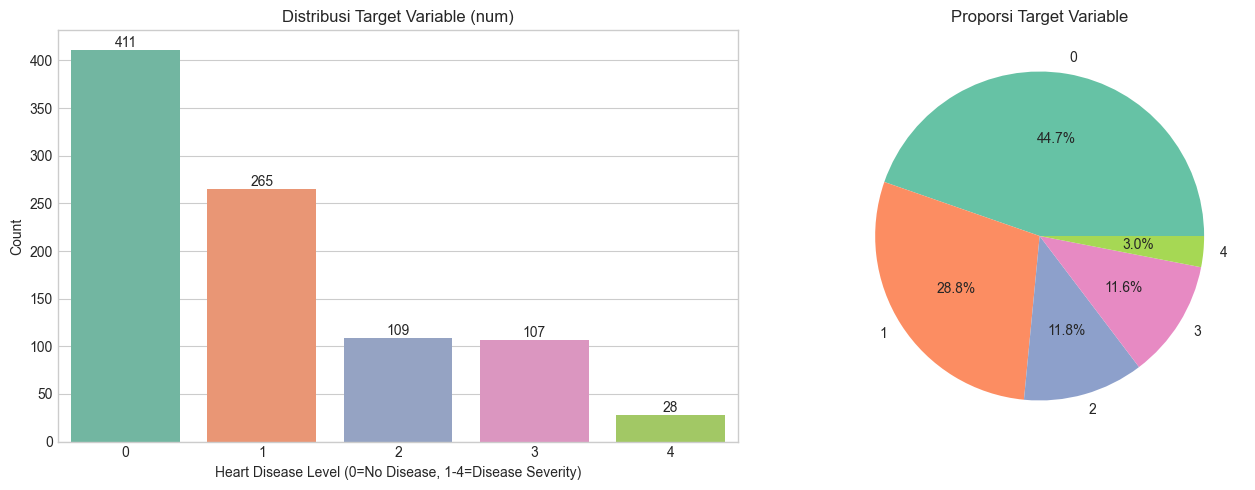

In [11]:
# Distribusi target variable
print("="*60)
print("DISTRIBUSI TARGET VARIABLE (num)")
print("="*60)
print(df['num'].value_counts())
print(f"\nPersentase:")
print(df['num'].value_counts(normalize=True) * 100)

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='num', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Target Variable (num)', fontsize=12)
axes[0].set_xlabel('Heart Disease Level (0=No Disease, 1-4=Disease Severity)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pie chart
df['num'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('Set2'))
axes[1].set_title('Proporsi Target Variable', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Distribusi Variabel Kategorikal

Kolom Kategorikal: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


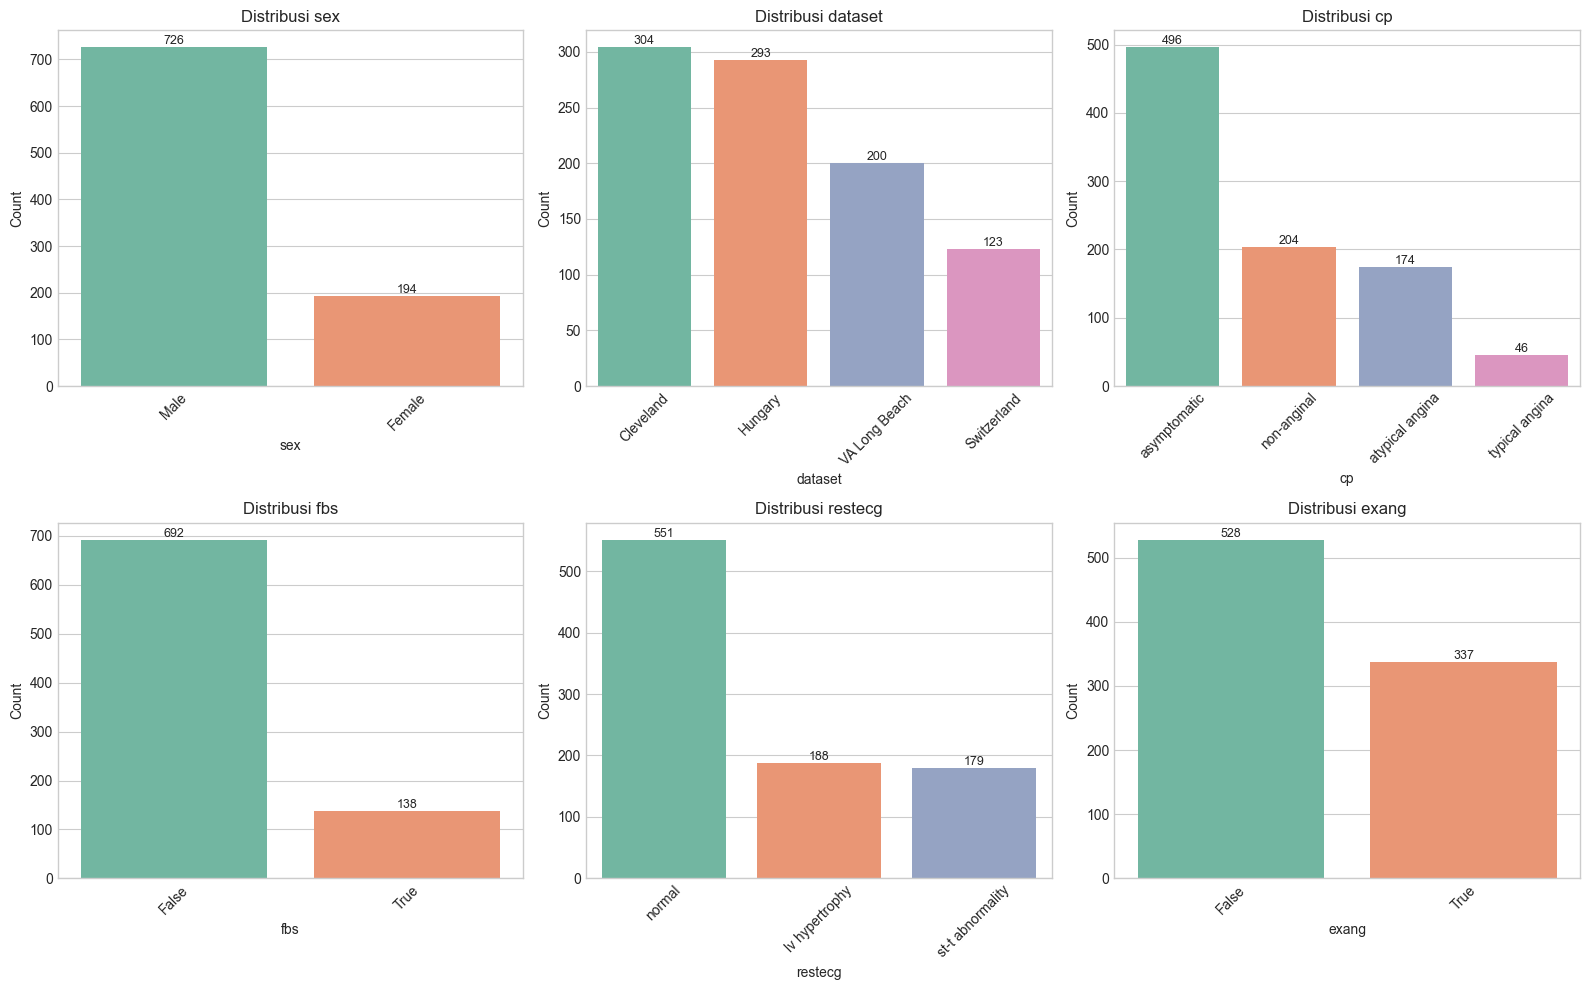

In [12]:
# Distribusi variabel kategorikal
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kolom Kategorikal: {categorical_cols}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'Distribusi {col}', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
        for p in axes[idx].patches:
            axes[idx].annotate(f'{int(p.get_height())}', 
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='bottom', fontsize=9)

# Hide unused subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Distribusi Variabel Numerik

Kolom Numerik: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


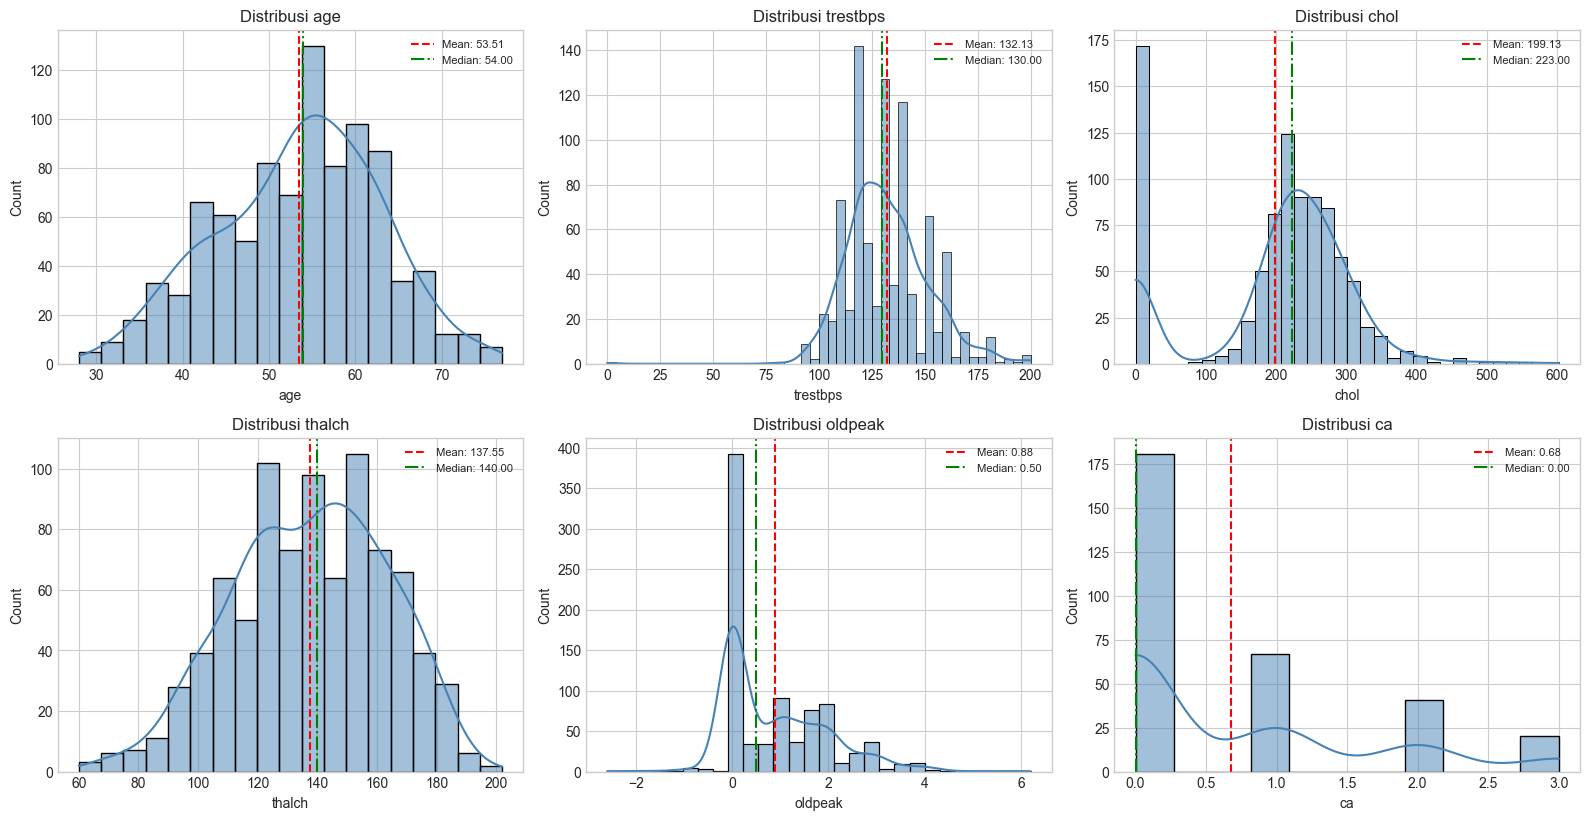

In [13]:
# Distribusi variabel numerik dengan histogram
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', 'num']]  # Exclude id and target
print(f"Kolom Numerik: {numerical_cols}")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'Distribusi {col}', fontsize=12)
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='-.', label=f'Median: {df[col].median():.2f}')
        axes[idx].legend(fontsize=8)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

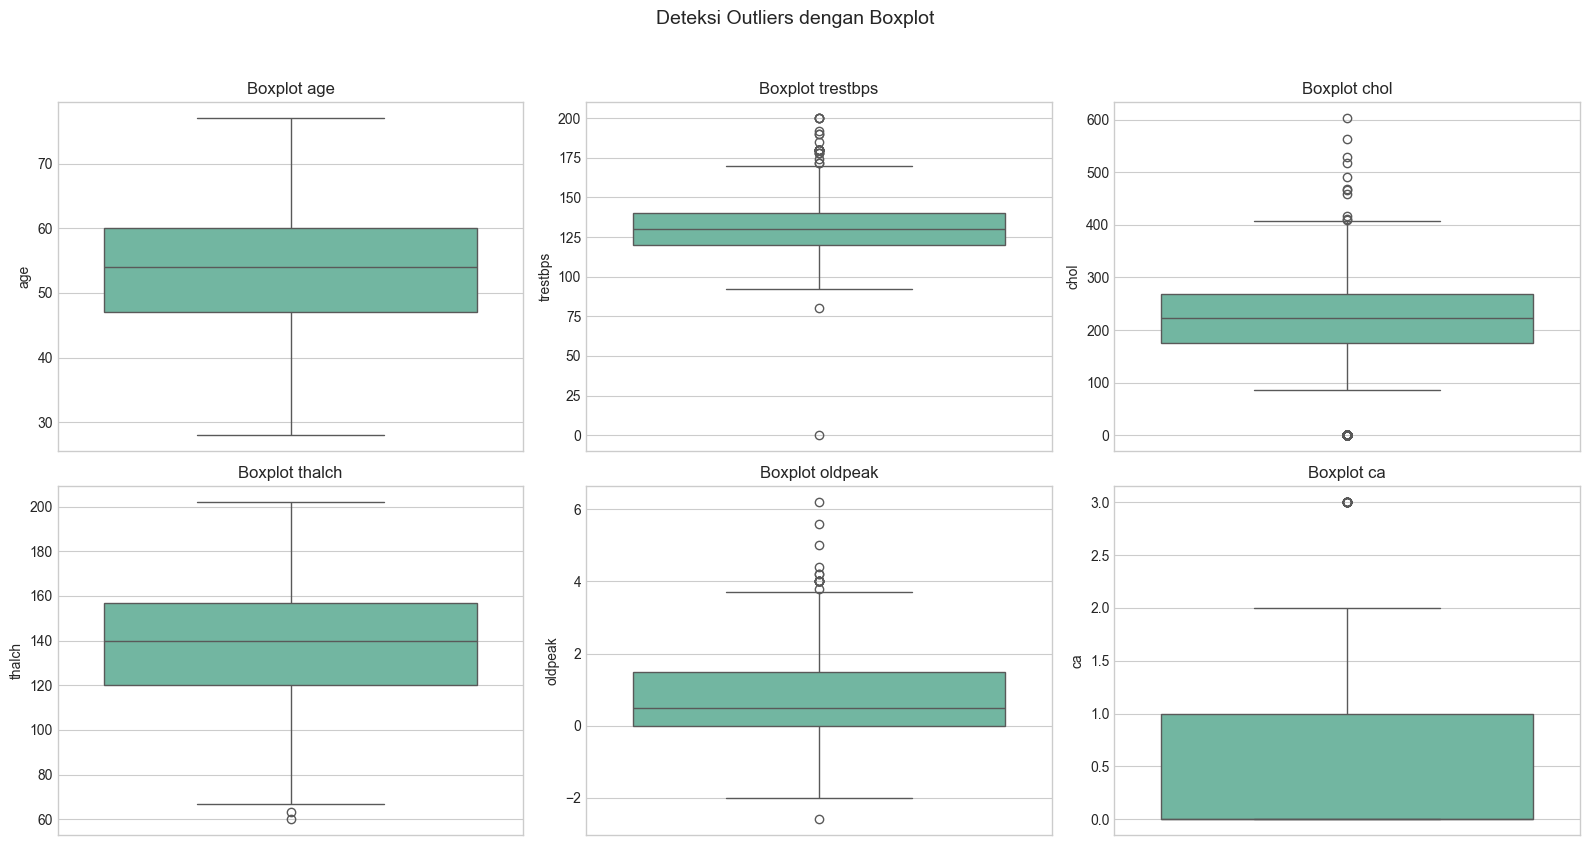

In [14]:
# Boxplot untuk deteksi outliers
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.boxplot(data=df, y=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'Boxplot {col}', fontsize=12)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Deteksi Outliers dengan Boxplot', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Analisis Korelasi

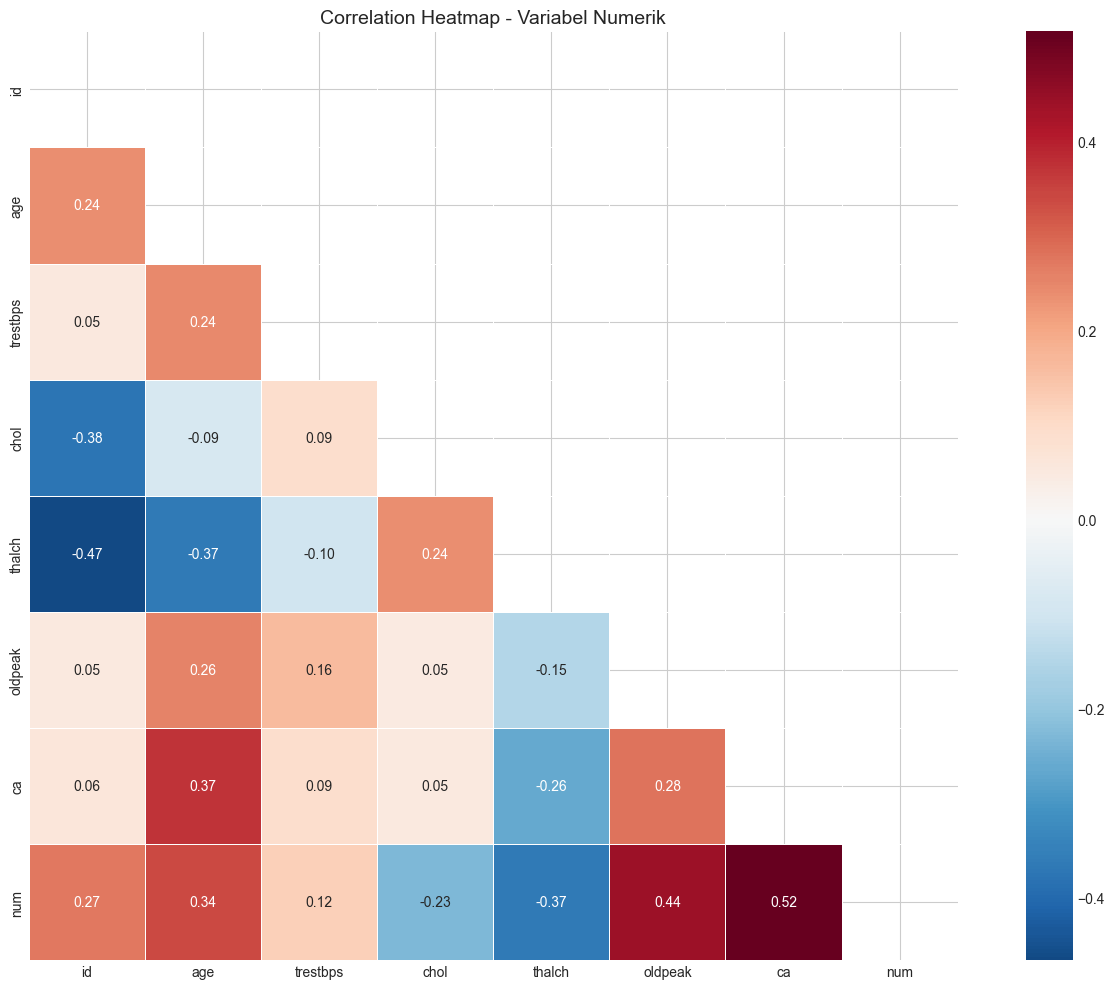

KORELASI DENGAN TARGET (num)
num         1.000000
ca          0.516216
oldpeak     0.443084
age         0.339596
id          0.273552
trestbps    0.122291
chol       -0.231547
thalch     -0.366265
Name: num, dtype: float64


In [15]:
# Heatmap korelasi
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Variabel Numerik', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("="*60)
print("KORELASI DENGAN TARGET (num)")
print("="*60)
target_corr = correlation_matrix['num'].sort_values(ascending=False)
print(target_corr)

## 8. Analisis Bivariat - Hubungan Fitur dengan Target

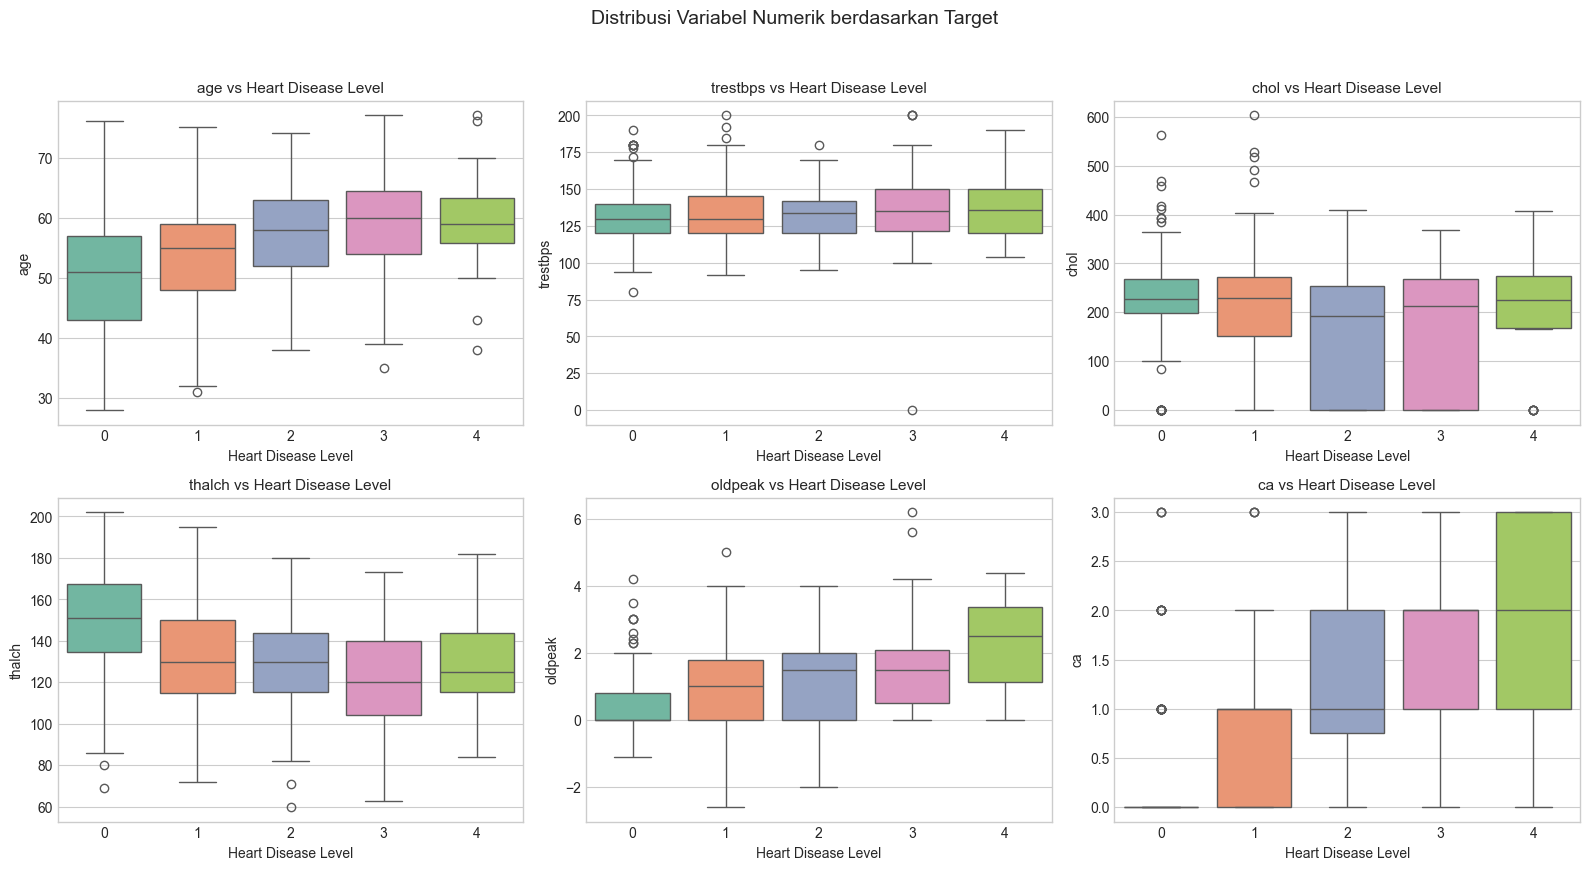

In [16]:
# Hubungan variabel numerik dengan target
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.boxplot(data=df, x='num', y=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'{col} vs Heart Disease Level', fontsize=11)
        axes[idx].set_xlabel('Heart Disease Level')

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Variabel Numerik berdasarkan Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

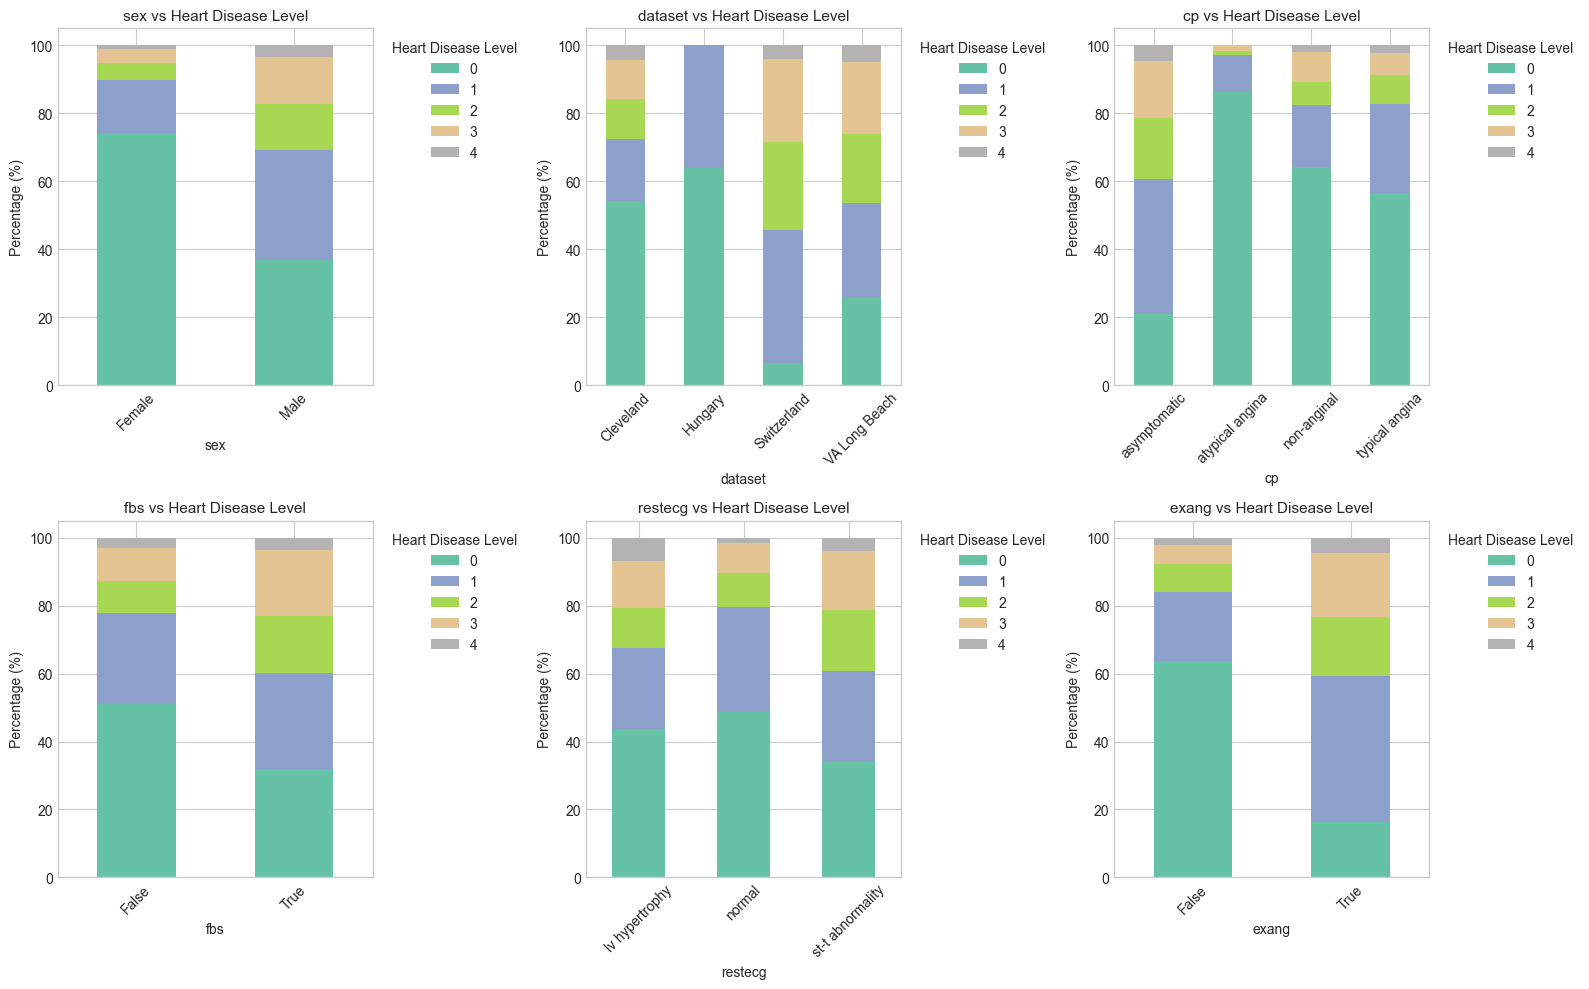

In [17]:
# Hubungan variabel kategorikal dengan target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        ct = pd.crosstab(df[col], df['num'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[idx], colormap='Set2')
        axes[idx].set_title(f'{col} vs Heart Disease Level', fontsize=11)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].legend(title='Heart Disease Level', bbox_to_anchor=(1.02, 1))
        axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Analisis Gender dan Usia

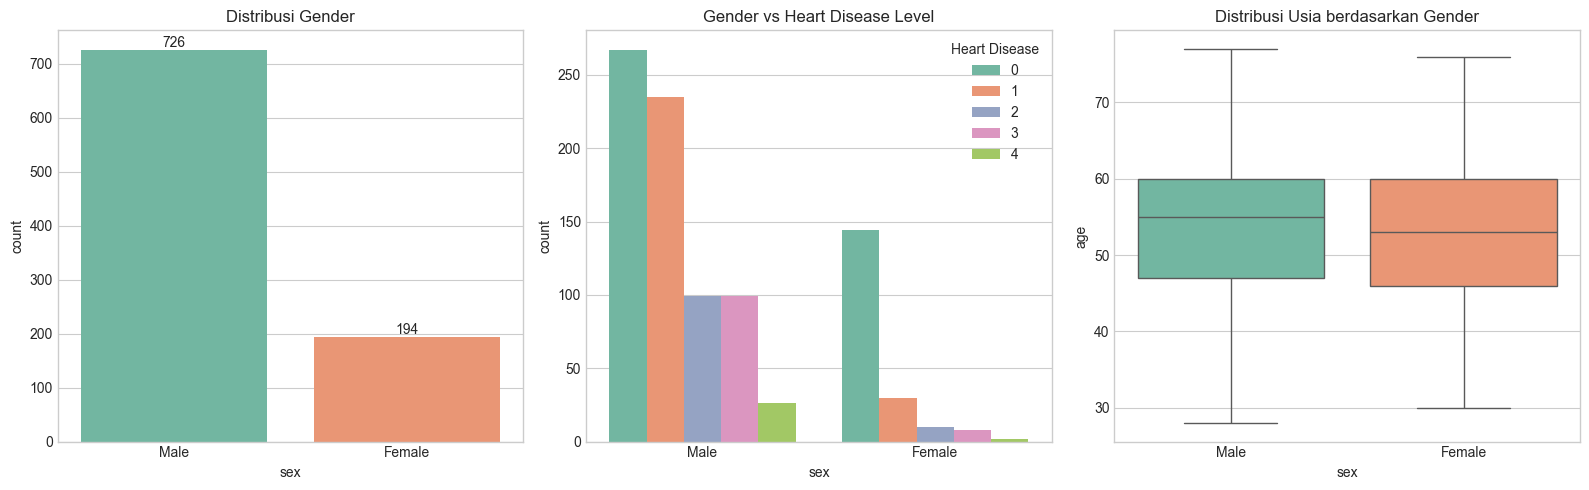

STATISTIK BERDASARKAN GENDER
num             0          1          2          3         4
sex                                                         
Female  74.226804  15.463918   5.154639   4.123711  1.030928
Male    36.776860  32.369146  13.636364  13.636364  3.581267


In [18]:
# Analisis Gender
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender distribution
sns.countplot(data=df, x='sex', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Gender', fontsize=12)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

# Gender vs Heart Disease
sns.countplot(data=df, x='sex', hue='num', ax=axes[1], palette='Set2')
axes[1].set_title('Gender vs Heart Disease Level', fontsize=12)
axes[1].legend(title='Heart Disease')

# Age distribution by gender
sns.boxplot(data=df, x='sex', y='age', ax=axes[2], palette='Set2')
axes[2].set_title('Distribusi Usia berdasarkan Gender', fontsize=12)

plt.tight_layout()
plt.show()

# Statistik Gender
print("="*60)
print("STATISTIK BERDASARKAN GENDER")
print("="*60)
print(df.groupby('sex')['num'].value_counts(normalize=True).unstack() * 100)

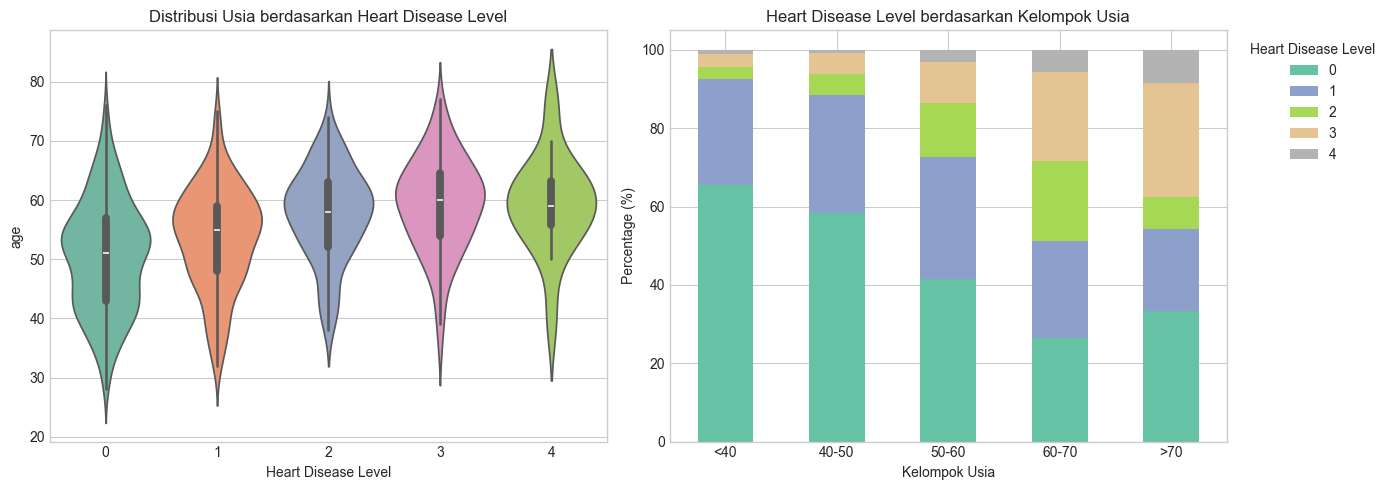

In [19]:
# Analisis Usia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by heart disease
sns.violinplot(data=df, x='num', y='age', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Usia berdasarkan Heart Disease Level', fontsize=12)
axes[0].set_xlabel('Heart Disease Level')

# Age groups analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 70, 100], 
                         labels=['<40', '40-50', '50-60', '60-70', '>70'])
age_disease = pd.crosstab(df['age_group'], df['num'], normalize='index') * 100
age_disease.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Heart Disease Level berdasarkan Kelompok Usia', fontsize=12)
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Heart Disease Level', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# Cell baru setelah import - Pemisahan Data untuk Uji Model

# Load dataset original
df_original = pd.read_csv('heart_disease_uci.csv')

print("="*60)
print("PEMISAHAN DATA UNTUK UJI MODEL")
print("="*60)
print(f"Total data original: {len(df_original)}")

# Buat target binary untuk stratified sampling
df_original['target_temp'] = (df_original['num'] > 0).astype(int)

# Pisahkan 100 data secara stratified untuk keperluan uji model
from sklearn.model_selection import train_test_split

df_training, df_uji = train_test_split(
    df_original, 
    test_size=100, 
    random_state=42, 
    stratify=df_original['target_temp']
)

# Hapus kolom temporary
df_training = df_training.drop(columns=['target_temp'])
df_uji = df_uji.drop(columns=['target_temp'])

# Simpan dataset uji (100 data) ke file CSV baru
df_uji.to_csv('heart_disease_uji_100.csv', index=False)

# Simpan dataset training (dikurangi 100) ke file CSV baru
df_training.to_csv('heart_disease_training.csv', index=False)

print(f"\n✓ Data untuk training: {len(df_training)} samples")
print(f"  → Disimpan ke: 'heart_disease_training.csv'")
print(f"\n✓ Data untuk uji model: {len(df_uji)} samples")
print(f"  → Disimpan ke: 'heart_disease_uji_100.csv'")

print("\n" + "="*60)
print("DISTRIBUSI TARGET PADA MASING-MASING DATASET")
print("="*60)
print("\nDataset Training:")
print((df_training['num'] > 0).astype(int).value_counts())
print("\nDataset Uji (100 data):")
print((df_uji['num'] > 0).astype(int).value_counts())

PEMISAHAN DATA UNTUK UJI MODEL
Total data original: 920

✓ Data untuk training: 820 samples
  → Disimpan ke: 'heart_disease_training.csv'

✓ Data untuk uji model: 100 samples
  → Disimpan ke: 'heart_disease_uji_100.csv'

DISTRIBUSI TARGET PADA MASING-MASING DATASET

Dataset Training:
num
1    454
0    366
Name: count, dtype: int64

Dataset Uji (100 data):
num
1    55
0    45
Name: count, dtype: int64


## 1. Data Preparation

Load dataset dan persiapkan target binary classification (0 = tidak ada penyakit, 1 = ada penyakit).

In [2]:
# Import libraries yang diperlukan
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import optuna
from optuna.samplers import TPESampler

# Suppress Optuna logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load dataset
df_ml = pd.read_csv('heart_disease_uci.csv')

# Konversi target ke binary classification
# 0 = tidak ada penyakit jantung, 1 = ada penyakit jantung (nilai 1-4 dijadikan 1)
df_ml['target'] = (df_ml['num'] > 0).astype(int)

# Definisikan fitur numerik dan kategorikal sesuai spesifikasi
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Pisahkan fitur (X) dan target (y)
X = df_ml[numerical_features + categorical_features]
y = df_ml['target']

print("="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Total samples: {len(X)}")
print(f"Fitur numerik: {numerical_features}")
print(f"Fitur kategorikal: {categorical_features}")
print(f"\nDistribusi target (binary):")
print(y.value_counts())
print(f"\nProporsi target:")
print(y.value_counts(normalize=True) * 100)

DATA PREPARATION
Total samples: 920
Fitur numerik: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Fitur kategorikal: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Distribusi target (binary):
target
1    509
0    411
Name: count, dtype: int64

Proporsi target:
target
1    55.326087
0    44.673913
Name: proportion, dtype: float64


In [4]:
# Train-Test Split dengan stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("="*60)
print("TRAIN-TEST SPLIT (80:20, Stratified)")
print("="*60)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nDistribusi target di training set:")
print(y_train.value_counts())
print(f"\nDistribusi target di test set:")
print(y_test.value_counts())

TRAIN-TEST SPLIT (80:20, Stratified)
Training set: 736 samples
Test set: 184 samples

Distribusi target di training set:
target
1    407
0    329
Name: count, dtype: int64

Distribusi target di test set:
target
1    102
0     82
Name: count, dtype: int64


## 2. Preprocessing Pipeline

Membangun preprocessing pipeline dengan ColumnTransformer:
- **Numerik**: Impute missing values dengan median
- **Kategorikal**: Impute missing values dengan most frequent, kemudian One-Hot Encoding

In [5]:
# Pipeline untuk fitur numerik (impute dengan median, tanpa scaling)
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    # Tidak ada scaling karena Random Forest tidak memerlukannya
])

# Pipeline untuk fitur kategorikal (impute dengan most frequent, lalu one-hot encoding)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gabungkan dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

print("="*60)
print("PREPROCESSING PIPELINE")
print("="*60)
print("✓ Numerical Pipeline: SimpleImputer (median)")
print("✓ Categorical Pipeline: SimpleImputer (most_frequent) → OneHotEncoder")
print("✓ Feature Scaling: TIDAK DIGUNAKAN")
print("\nAlasan: Random Forest adalah model berbasis decision tree yang")
print("membuat split berdasarkan threshold, sehingga invariant terhadap")
print("monotonic transformations seperti scaling.")

PREPROCESSING PIPELINE
✓ Numerical Pipeline: SimpleImputer (median)
✓ Categorical Pipeline: SimpleImputer (most_frequent) → OneHotEncoder
✓ Feature Scaling: TIDAK DIGUNAKAN

Alasan: Random Forest adalah model berbasis decision tree yang
membuat split berdasarkan threshold, sehingga invariant terhadap
monotonic transformations seperti scaling.


## 3 & 4. Hyperparameter Optimization dengan Optuna

Menggunakan Stratified K-Fold CV (k=5) untuk optimasi hyperparameter Random Forest dengan objective metric **Accuracy**.

In [6]:
# Definisikan objective function untuk Optuna
def objective(trial):
    """
    Objective function untuk hyperparameter optimization.
    Menggunakan Stratified K-Fold CV dengan k=5.
    """
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    # Buat Random Forest dengan hyperparameters yang disarankan
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Buat full pipeline (preprocessor + classifier)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf)
    ])
    
    # Stratified K-Fold Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Hitung cross-validation score (accuracy)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return scores.mean()

print("Objective function defined successfully!")
print("\nHyperparameter search space:")
print("- n_estimators: 100-500")
print("- max_depth: 3-30")
print("- min_samples_split: 2-20")
print("- min_samples_leaf: 1-10")
print("- max_features: ['sqrt', 'log2']")

Objective function defined successfully!

Hyperparameter search space:
- n_estimators: 100-500
- max_depth: 3-30
- min_samples_split: 2-20
- min_samples_leaf: 1-10
- max_features: ['sqrt', 'log2']


In [7]:
# Jalankan Optuna optimization
print("="*60)
print("OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*60)
print("Running 20 trials with TPE sampler...")
print("Objective: Maximize Accuracy (5-Fold Stratified CV)")
print("-"*60)

# Create Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

# Optimize dengan 20 trials
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETED!")
print("="*60)
print(f"\nBest trial accuracy (CV): {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

OPTUNA HYPERPARAMETER OPTIMIZATION
Running 20 trials with TPE sampler...
Objective: Maximize Accuracy (5-Fold Stratified CV)
------------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]


OPTIMIZATION COMPLETED!

Best trial accuracy (CV): 0.8139

Best hyperparameters:
  - n_estimators: 196
  - max_depth: 20
  - min_samples_split: 12
  - min_samples_leaf: 3
  - max_features: log2


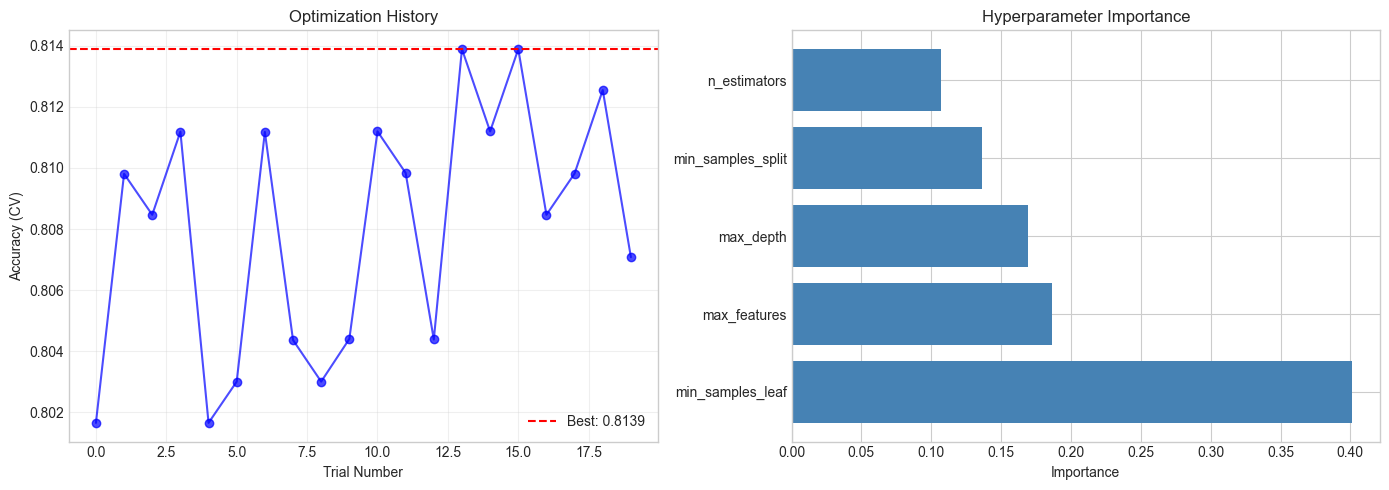

In [8]:
# Visualisasi optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'b-o', alpha=0.7)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Accuracy (CV)')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Hyperparameter importance
param_importance = optuna.importance.get_param_importances(study)
params = list(param_importance.keys())
importances = list(param_importance.values())
axes[1].barh(params, importances, color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.show()

## 5. Training Model Final

Melatih model dengan best hyperparameters menggunakan seluruh data training.

In [9]:
# Buat model final dengan best hyperparameters
best_params = study.best_params

final_rf = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Buat final pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_rf)
])

# Train pada seluruh data training
print("="*60)
print("TRAINING FINAL MODEL")
print("="*60)
final_pipeline.fit(X_train, y_train)
print("✓ Model trained successfully on full training data!")
print(f"\nFinal model hyperparameters:")
for key, value in best_params.items():
    print(f"  - {key}: {value}")

TRAINING FINAL MODEL
✓ Model trained successfully on full training data!

Final model hyperparameters:
  - n_estimators: 196
  - max_depth: 20
  - min_samples_split: 12
  - min_samples_leaf: 3
  - max_features: log2


## 6. Evaluasi Model

Evaluasi performa model pada test set menggunakan Accuracy, ROC-AUC, dan Classification Report.

In [10]:
# Prediksi pada test set
y_pred = final_pipeline.predict(X_test)
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Hitung metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("="*60)
print("EVALUASI MODEL PADA TEST SET")
print("="*60)
print(f"\n📊 METRICS:")
print(f"   • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • ROC-AUC:   {roc_auc:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

EVALUASI MODEL PADA TEST SET

📊 METRICS:
   • Accuracy:  0.8533 (85.33%)
   • ROC-AUC:   0.9265

CLASSIFICATION REPORT
                precision    recall  f1-score   support

No Disease (0)       0.85      0.82      0.83        82
   Disease (1)       0.86      0.88      0.87       102

      accuracy                           0.85       184
     macro avg       0.85      0.85      0.85       184
  weighted avg       0.85      0.85      0.85       184



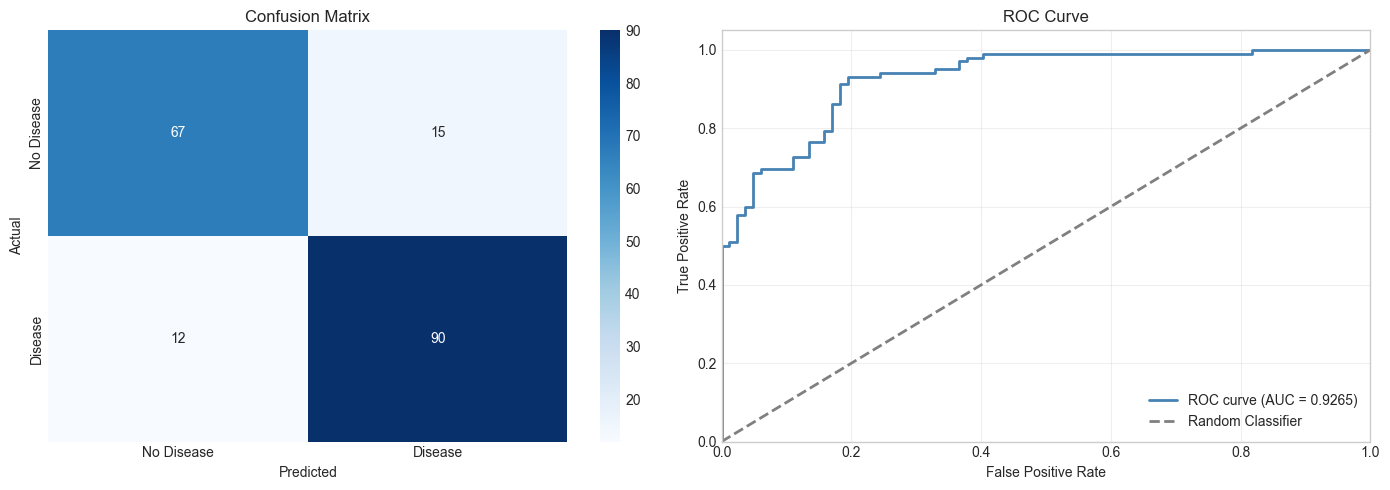

In [11]:
# Visualisasi Confusion Matrix dan ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance

Menampilkan Top-10 fitur paling penting dalam prediksi penyakit jantung.

In [12]:
# Ekstrak feature names setelah preprocessing
# Get feature names from the preprocessor
ohe = final_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + cat_feature_names

# Get feature importances dari Random Forest
feature_importances = final_pipeline.named_steps['classifier'].feature_importances_

# Buat DataFrame feature importance
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Top-10 Feature Importance
print("="*60)
print("TOP-10 FEATURE IMPORTANCE")
print("="*60)
top_10 = importance_df.head(10).reset_index(drop=True)
top_10.index = top_10.index + 1
print(top_10.to_string())

TOP-10 FEATURE IMPORTANCE
               Feature  Importance
1      cp_asymptomatic    0.123381
2                 chol    0.099552
3                  age    0.094779
4          exang_False    0.091478
5              oldpeak    0.087736
6               thalch    0.086983
7           exang_True    0.082453
8   cp_atypical angina    0.057227
9             trestbps    0.038257
10          sex_Female    0.035449


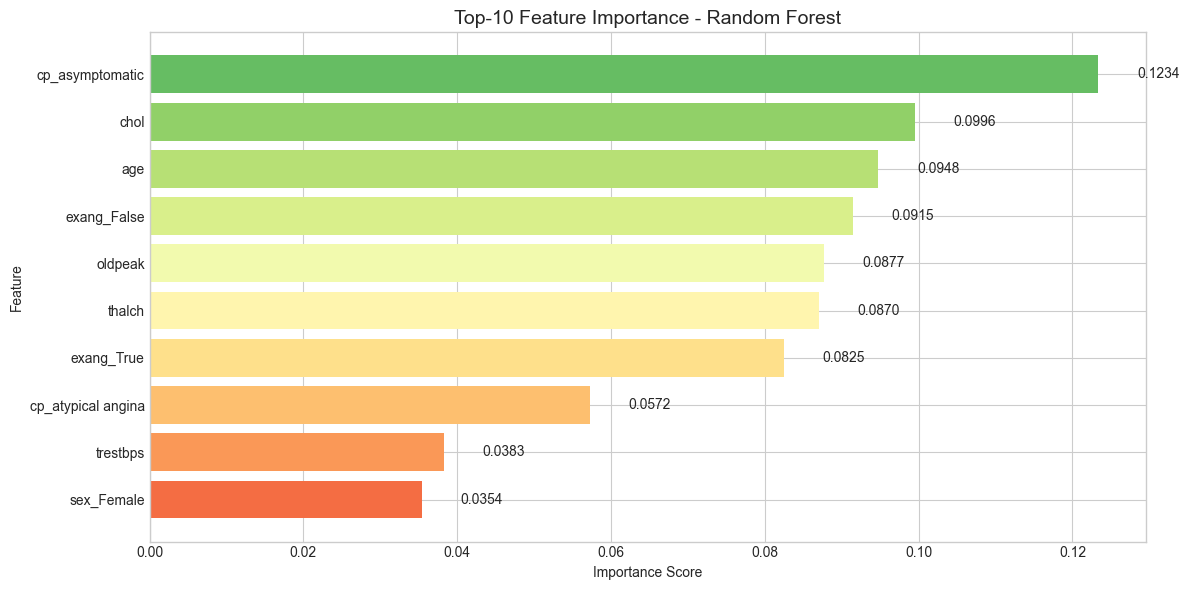

In [13]:
# Visualisasi Top-10 Feature Importance
plt.figure(figsize=(12, 6))
top_10_plot = importance_df.head(10)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 10))[::-1]
bars = plt.barh(top_10_plot['Feature'], top_10_plot['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top-10 Feature Importance - Random Forest', fontsize=14)
plt.gca().invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_10_plot['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 📋 Ringkasan Hasil Eksperimen

In [14]:
# Ringkasan hasil eksperimen
print("="*70)
print("📋 RINGKASAN HASIL EKSPERIMEN")
print("="*70)

print("\n🔹 DATASET:")
print(f"   • Total samples: {len(X)}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Test samples: {len(X_test)}")
print(f"   • Fitur numerik: {len(numerical_features)}")
print(f"   • Fitur kategorikal: {len(categorical_features)}")

print("\n🔹 PREPROCESSING:")
print("   • Missing values (numerik): Median imputation")
print("   • Missing values (kategorikal): Most frequent imputation")
print("   • Encoding: One-Hot Encoding")
print("   • Scaling: TIDAK DIGUNAKAN")

print("\n🔹 HYPERPARAMETER OPTIMIZATION:")
print(f"   • Method: Optuna (TPE Sampler)")
print(f"   • Trials: 20")
print(f"   • Cross-Validation: 5-Fold Stratified")
print(f"   • Best CV Accuracy: {study.best_value:.4f}")

print("\n🔹 BEST HYPERPARAMETERS:")
for key, value in best_params.items():
    print(f"   • {key}: {value}")

print("\n🔹 EVALUASI TEST SET:")
print(f"   • Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • ROC-AUC: {roc_auc:.4f}")

print("\n🔹 TOP-3 FITUR PENTING:")
for idx, row in importance_df.head(3).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*70)
print("📝 CATATAN METODOLOGIS:")
print("="*70)
print("""
Feature scaling (StandardScaler/MinMaxScaler) TIDAK digunakan karena:
1. Random Forest adalah ensemble dari decision trees
2. Decision trees membuat split berdasarkan threshold nilai fitur
3. Proses splitting tidak terpengaruh oleh skala nilai fitur
4. Model ini invariant terhadap monotonic transformations
5. Scaling hanya menambah kompleksitas tanpa meningkatkan performa
""")

📋 RINGKASAN HASIL EKSPERIMEN

🔹 DATASET:
   • Total samples: 920
   • Training samples: 736
   • Test samples: 184
   • Fitur numerik: 5
   • Fitur kategorikal: 8

🔹 PREPROCESSING:
   • Missing values (numerik): Median imputation
   • Missing values (kategorikal): Most frequent imputation
   • Encoding: One-Hot Encoding
   • Scaling: TIDAK DIGUNAKAN

🔹 HYPERPARAMETER OPTIMIZATION:
   • Method: Optuna (TPE Sampler)
   • Trials: 20
   • Cross-Validation: 5-Fold Stratified
   • Best CV Accuracy: 0.8139

🔹 BEST HYPERPARAMETERS:
   • n_estimators: 196
   • max_depth: 20
   • min_samples_split: 12
   • min_samples_leaf: 3
   • max_features: log2

🔹 EVALUASI TEST SET:
   • Accuracy: 0.8533 (85.33%)
   • ROC-AUC: 0.9265

🔹 TOP-3 FITUR PENTING:
   8. cp_asymptomatic: 0.1234
   3. chol: 0.0996
   1. age: 0.0948

📝 CATATAN METODOLOGIS:

Feature scaling (StandardScaler/MinMaxScaler) TIDAK digunakan karena:
1. Random Forest adalah ensemble dari decision trees
2. Decision trees membuat split berdasa

EVALUASI MODEL PADA 100 DATA UJI TERPISAH

📊 METRICS PADA 100 DATA UJI:
   • Accuracy:  0.8500 (85.00%)
   • ROC-AUC:   0.9119

CLASSIFICATION REPORT (100 Data Uji)
                precision    recall  f1-score   support

No Disease (0)       0.88      0.78      0.82        45
   Disease (1)       0.83      0.91      0.87        55

      accuracy                           0.85       100
     macro avg       0.85      0.84      0.85       100
  weighted avg       0.85      0.85      0.85       100



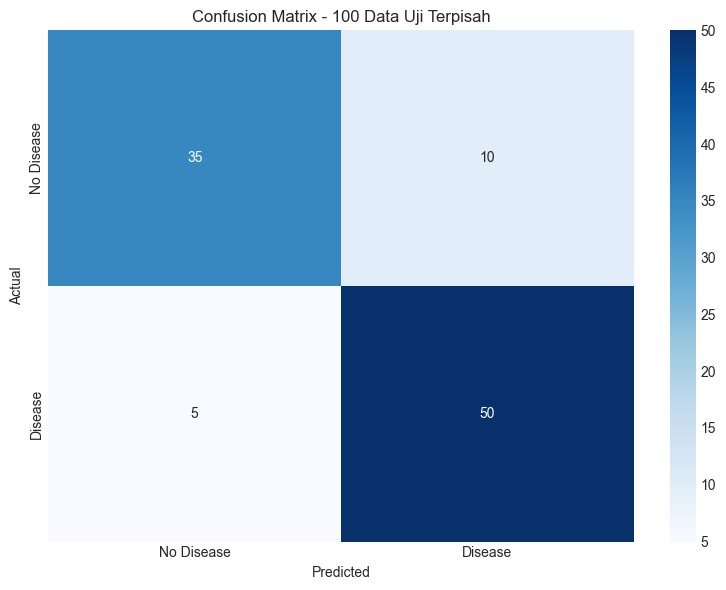


PERBANDINGAN PERFORMA
Dataset                   Accuracy        ROC-AUC        
-------------------------------------------------------
Test Set (30% split)      0.8533           0.9265
100 Data Uji Terpisah     0.8500           0.9119


In [15]:
# Evaluasi model menggunakan 100 data uji yang dipisahkan sebelumnya
print("="*70)
print("EVALUASI MODEL PADA 100 DATA UJI TERPISAH")
print("="*70)

# Load 100 data uji
df_uji_100 = pd.read_csv('heart_disease_uji_100.csv')

# Siapkan fitur dan target
X_uji_100 = df_uji_100[numerical_features + categorical_features]
y_uji_100 = (df_uji_100['num'] > 0).astype(int)

# Prediksi dengan model final
y_pred_uji = final_pipeline.predict(X_uji_100)
y_pred_proba_uji = final_pipeline.predict_proba(X_uji_100)[:, 1]

# Hitung metrics
accuracy_uji = accuracy_score(y_uji_100, y_pred_uji)
roc_auc_uji = roc_auc_score(y_uji_100, y_pred_proba_uji)

print(f"\n📊 METRICS PADA 100 DATA UJI:")
print(f"   • Accuracy:  {accuracy_uji:.4f} ({accuracy_uji*100:.2f}%)")
print(f"   • ROC-AUC:   {roc_auc_uji:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT (100 Data Uji)")
print("="*60)
print(classification_report(y_uji_100, y_pred_uji, target_names=['No Disease (0)', 'Disease (1)']))

# Confusion Matrix untuk 100 data uji
plt.figure(figsize=(8, 6))
cm_uji = confusion_matrix(y_uji_100, y_pred_uji)
sns.heatmap(cm_uji, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - 100 Data Uji Terpisah', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PERBANDINGAN PERFORMA")
print("="*70)
print(f"{'Dataset':<25} {'Accuracy':<15} {'ROC-AUC':<15}")
print("-"*55)
print(f"{'Test Set (30% split)':<25} {accuracy:.4f}{'':<10} {roc_auc:.4f}")
print(f"{'100 Data Uji Terpisah':<25} {accuracy_uji:.4f}{'':<10} {roc_auc_uji:.4f}")